# CS3807 -- Deep Learning Laboratory -- Experiment 5

**Comprehensive Study of CNN Training, Regularization, Optimization, Hyperparameter Tuning, Transfer Learning and Cross-Validation**

Name: R S Kirithic
Register Number: 24011101082

Model: MobileNetV2 (ImageNet pretrained)
Dataset: Oxford-IIIT Pet Dataset (37 breeds)

---

**A note on the approach used in this notebook**

Every section in the manual before Section 10 (weight initialisation, regularisation, batch
normalisation, optimizers, hyperparameter tuning) trains a classifier on top of a **frozen**
MobileNetV2 backbone. Because the backbone never updates in any of these studies, its output
for a given image is always the same number -- so instead of re-running the full convolutional
backbone on every image for every one of the ~40 short training runs in this notebook, the
backbone is run **once** over the whole dataset and the resulting 1280-dimensional feature
vectors ("bottleneck features") are cached. Every study up to and including the 5-fold
cross-validation section then trains only the small dense head on these cached features, which
is mathematically identical to running the frozen backbone every epoch, just far faster.

Only Section 10 (Transfer Learning and Fine-Tuning) and the final retraining in Section 12 do
real end-to-end training on actual images, because fine-tuning unfreezes part of the backbone,
so its output is no longer fixed and cannot be cached.

All figures are saved as `.eps` at 600 DPI in the `figures/` folder, using Times New Roman,
matching the house style used for Experiment 4.


## 0. Setup

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Allow GPU memory to grow instead of pre-allocating everything (RTX 4070 Ti)
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("TensorFlow:", tf.__version__)
print("GPUs available:", gpus)


TensorFlow: 2.10.1
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Plot styling: Times New Roman, size 13, figures saved as EPS at 600 DPI
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 13
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['axes.labelsize'] = 13

os.makedirs('figures', exist_ok=True)

def save_fig(fig, name):
    path = f'figures/{name}.eps'
    fig.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    print(f"Saved {path}")


## 1. Dataset: Oxford-IIIT Pet

Loaded through `tensorflow_datasets`. The official `train` split (3,680 images) is further
split 90/10 into a training set and a validation set. The official `test` split (3,669 images)
is kept completely untouched until Section 12, exactly as the manual requires.


In [4]:
IMG_SIZE = 224
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

(train_raw, val_raw, test_raw), ds_info = tfds.load(
    'oxford_iiit_pet',
    split=['train[:90%]', 'train[90%:]', 'test'],
    with_info=True,
    as_supervised=True
)

NUM_CLASSES = ds_info.features['label'].num_classes
CLASS_NAMES = ds_info.features['label'].names

n_train_full = ds_info.splits['train'].num_examples
n_test = ds_info.splits['test'].num_examples
n_train = int(round(n_train_full * 0.9))
n_val = n_train_full - n_train

print(f"Classes: {NUM_CLASSES}")
print(f"Train: {n_train}  Val: {n_val}  Test: {n_test}")


Classes: 37
Train: 3312  Val: 368  Test: 3669


In [5]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

def make_ds(ds, batch_size=BATCH, shuffle=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_raw, shuffle=False)   # no shuffle: order must match bottleneck extraction
val_ds = make_ds(val_raw)
test_ds = make_ds(test_raw)


## 2. Bottleneck Feature Extraction (Frozen MobileNetV2 Base)

Loads MobileNetV2 with ImageNet weights, removes the classification head, freezes the base, and
runs every image through it once. `pooling='avg'` applies Global Average Pooling at the output,
giving a 1280-dimensional feature vector per image -- this is exactly "Case A: Feature Extraction"
from Section 10 of the manual, cached for re-use across Sections 5-9 and 11.


In [6]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False
print("MobileNetV2 base parameters:", base_model.count_params())


MobileNetV2 base parameters: 2257984


In [7]:
def extract_features(ds):
    feats, labels = [], []
    for images, lbls in ds:
        f = base_model.predict(images, verbose=0)
        feats.append(f)
        labels.append(lbls.numpy())
    return np.concatenate(feats), np.concatenate(labels)

print("Extracting bottleneck features (single pass through the frozen backbone)...")
t0 = time.time()
X_train, y_train_int = extract_features(train_ds)
X_val, y_val_int = extract_features(val_ds)
X_test, y_test_int = extract_features(test_ds)
print(f"Done in {time.time() - t0:.1f} s")
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

y_train = tf.keras.utils.to_categorical(y_train_int, NUM_CLASSES)
y_val = tf.keras.utils.to_categorical(y_val_int, NUM_CLASSES)
y_test = tf.keras.utils.to_categorical(y_test_int, NUM_CLASSES)


Extracting bottleneck features (single pass through the frozen backbone)...
Done in 12.1 s
Shapes: (3312, 1280) (368, 1280) (3669, 1280)


## Helper functions used throughout the notebook

`build_head` builds the small classifier that sits on the 1280-dimensional bottleneck features
(Dense(128, ReLU) -> optional BatchNorm -> optional Dropout -> Dense(37, Softmax)).
`make_optimizer` builds a fresh optimizer instance by name so the same optimizer choice can be
reused across sections without state leaking between training runs.


In [8]:
from tensorflow.keras.regularizers import l2

def build_head(init='glorot_uniform', reg=None, dropout_rate=0.0, use_bn=False, hidden_units=128):
    inputs = tf.keras.Input(shape=(1280,))
    x = tf.keras.layers.Dense(hidden_units, activation='relu',
                               kernel_initializer=init, kernel_regularizer=reg)(inputs)
    if use_bn:
        x = tf.keras.layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', kernel_initializer=init)(x)
    return tf.keras.Model(inputs, outputs)

def make_optimizer(name, lr):
    if name == 'SGD':
        return tf.keras.optimizers.SGD(learning_rate=lr)
    elif name == 'Momentum':
        return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif name == 'RMSProp':
        return tf.keras.optimizers.RMSprop(learning_rate=lr)
    elif name == 'Adam':
        return tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        raise ValueError(name)

def compile_and_train(model, optimizer, X_tr, y_tr, X_va, y_va, epochs=20, batch_size=32, verbose=0):
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    t0 = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                         epochs=epochs, batch_size=batch_size, verbose=verbose)
    return history, time.time() - t0


## Baseline Model

Before any of the studies below, a plain baseline is trained with no special initialisation
choice, no regularisation, and the Adam optimizer at its default learning rate. This gives a
reference point for the Overall Results table in Section 13 of the manual.


In [9]:
print("Training baseline model (default Glorot init, no regularisation, Adam 0.001)...")
baseline_model = build_head()
baseline_history, baseline_time = compile_and_train(
    baseline_model, tf.keras.optimizers.Adam(0.001), X_train, y_train, X_val, y_val, epochs=20
)
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline best val. accuracy: {max(baseline_history.history['val_accuracy'])*100:.2f}%")
print(f"Baseline test accuracy: {baseline_test_acc*100:.2f}%")


Training baseline model (default Glorot init, no regularisation, Adam 0.001)...
Baseline best val. accuracy: 92.93%
Baseline test accuracy: 90.43%


## Section 5: Weight Initialization

Four initialisation strategies for the head's Dense layers: Zero, Random (small Gaussian),
Xavier/Glorot, and He. Everything else (optimizer, batch size, epochs) is held fixed so only
the initialisation differs.


In [10]:
init_methods = {
    'Zero': 'zeros',
    'Random': tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED),
    'Xavier/Glorot': 'glorot_uniform',
    'He': 'he_normal',
}

EPOCHS_INIT = 20
init_histories, init_models, init_times = {}, {}, {}

for name, init in init_methods.items():
    print(f"Training with {name} initialization...")
    model = build_head(init=init)
    history, elapsed = compile_and_train(model, tf.keras.optimizers.Adam(0.001),
                                          X_train, y_train, X_val, y_val, epochs=EPOCHS_INIT)
    init_histories[name] = history.history
    init_models[name] = model
    init_times[name] = elapsed


Training with Zero initialization...
Training with Random initialization...
Training with Xavier/Glorot initialization...
Training with He initialization...


Saved figures/plot1_init_train_loss.eps


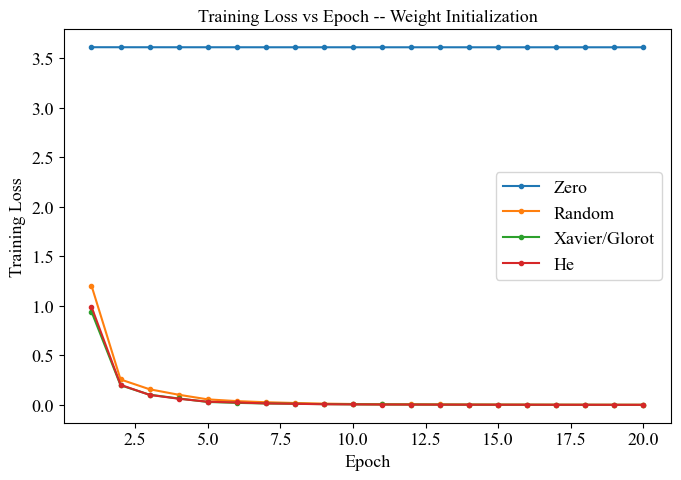

In [11]:
# Plot 1: Training Loss vs Epoch
fig, ax = plt.subplots(figsize=(7, 5))
for name, h in init_histories.items():
    ax.plot(range(1, len(h['loss']) + 1), h['loss'], label=name, marker='o', markersize=3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Training Loss')
ax.set_title('Training Loss vs Epoch -- Weight Initialization')
ax.legend()
plt.tight_layout()
save_fig(fig, 'plot1_init_train_loss')
plt.show()


Saved figures/plot2_init_val_acc.eps


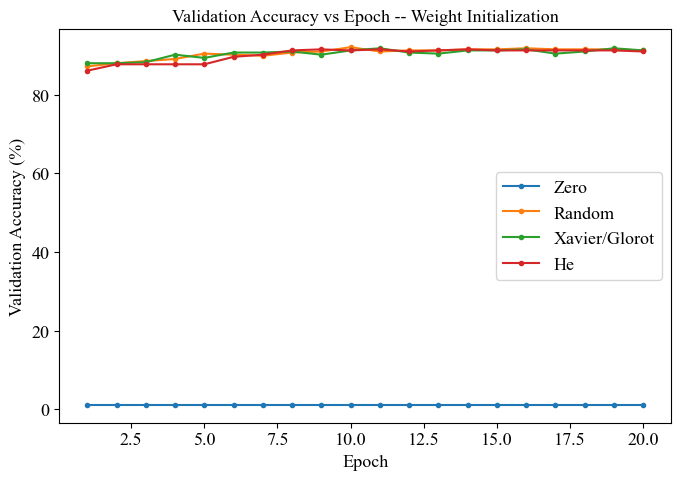

In [12]:
# Plot 2: Validation Accuracy vs Epoch
fig, ax = plt.subplots(figsize=(7, 5))
for name, h in init_histories.items():
    ax.plot(range(1, len(h['val_accuracy']) + 1), [v * 100 for v in h['val_accuracy']],
            label=name, marker='o', markersize=3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Validation Accuracy vs Epoch -- Weight Initialization')
ax.legend()
plt.tight_layout()
save_fig(fig, 'plot2_init_val_acc')
plt.show()


In [13]:
init_test_acc = {name: m.evaluate(X_test, y_test, verbose=0)[1] * 100 for name, m in init_models.items()}
best_init_name = max(init_histories, key=lambda n: max(init_histories[n]['val_accuracy']))
best_init = init_methods[best_init_name]
print(f"Best initialization: {best_init_name}")
print("Test accuracy by initialization:", {k: round(v, 2) for k, v in init_test_acc.items()})


Best initialization: Random
Test accuracy by initialization: {'Zero': 2.73, 'Random': 89.97, 'Xavier/Glorot': 89.97, 'He': 89.75}


## Section 6: Regularization and Overfitting

Four configurations, all using the best initialisation found above: No regularisation, L2
regularisation, Dropout, and Batch Normalization. Trained for more epochs than the previous
section specifically so a generalisation gap has a chance to show up.


In [14]:
reg_configs = {
    'No Regularization': dict(reg=None, dropout_rate=0.0, use_bn=False),
    'L2 Regularization': dict(reg=l2(0.01), dropout_rate=0.0, use_bn=False),
    'Dropout': dict(reg=None, dropout_rate=0.5, use_bn=False),
    'Batch Normalization': dict(reg=None, dropout_rate=0.0, use_bn=True),
}

EPOCHS_REG = 40
reg_histories, reg_models, reg_times = {}, {}, {}

for name, cfg in reg_configs.items():
    print(f"Training with {name}...")
    model = build_head(init=best_init, **cfg)
    history, elapsed = compile_and_train(model, tf.keras.optimizers.Adam(0.001),
                                          X_train, y_train, X_val, y_val, epochs=EPOCHS_REG)
    reg_histories[name] = history.history
    reg_models[name] = model
    reg_times[name] = elapsed


Training with No Regularization...
Training with L2 Regularization...
Training with Dropout...
Training with Batch Normalization...


Saved figures/plot3_reg_accuracy.eps


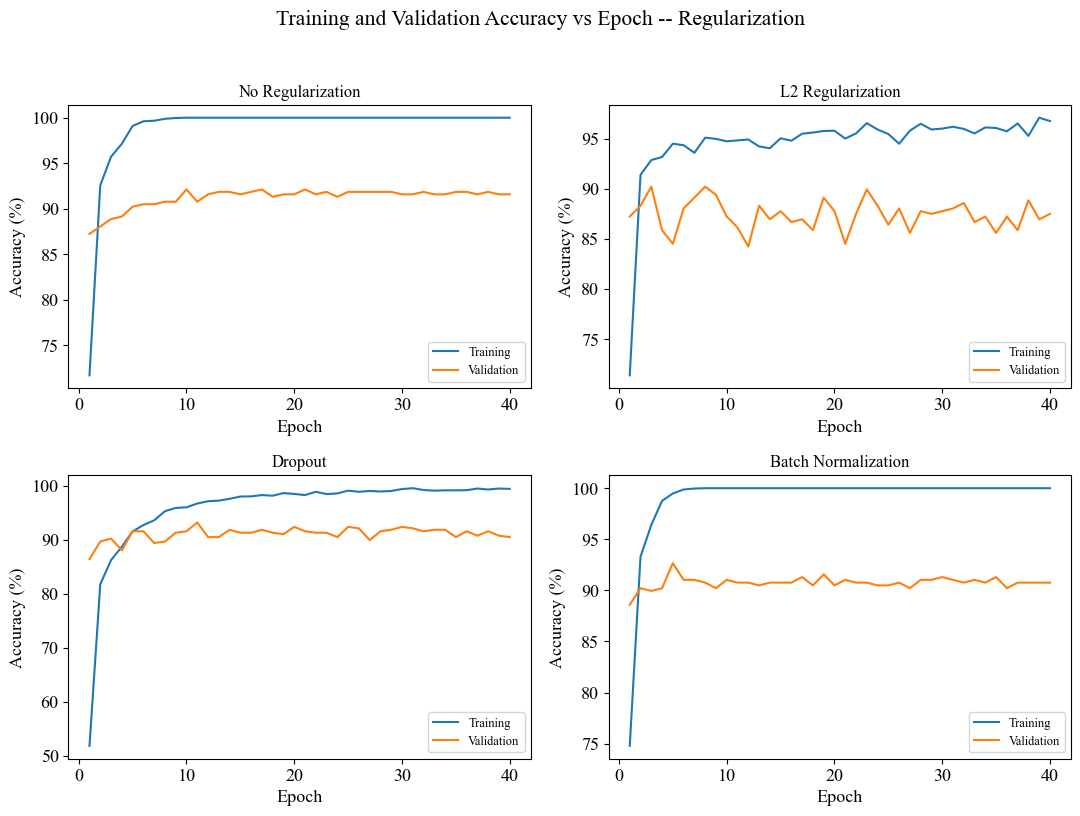

In [15]:
# Plot 3: Training and Validation Accuracy vs Epoch (one panel per technique)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (name, h) in zip(axes.flat, reg_histories.items()):
    ep = range(1, len(h['accuracy']) + 1)
    ax.plot(ep, [v * 100 for v in h['accuracy']], label='Training')
    ax.plot(ep, [v * 100 for v in h['val_accuracy']], label='Validation')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=9)
fig.suptitle('Training and Validation Accuracy vs Epoch -- Regularization', y=1.02)
plt.tight_layout()
save_fig(fig, 'plot3_reg_accuracy')
plt.show()


Saved figures/plot4_reg_loss.eps


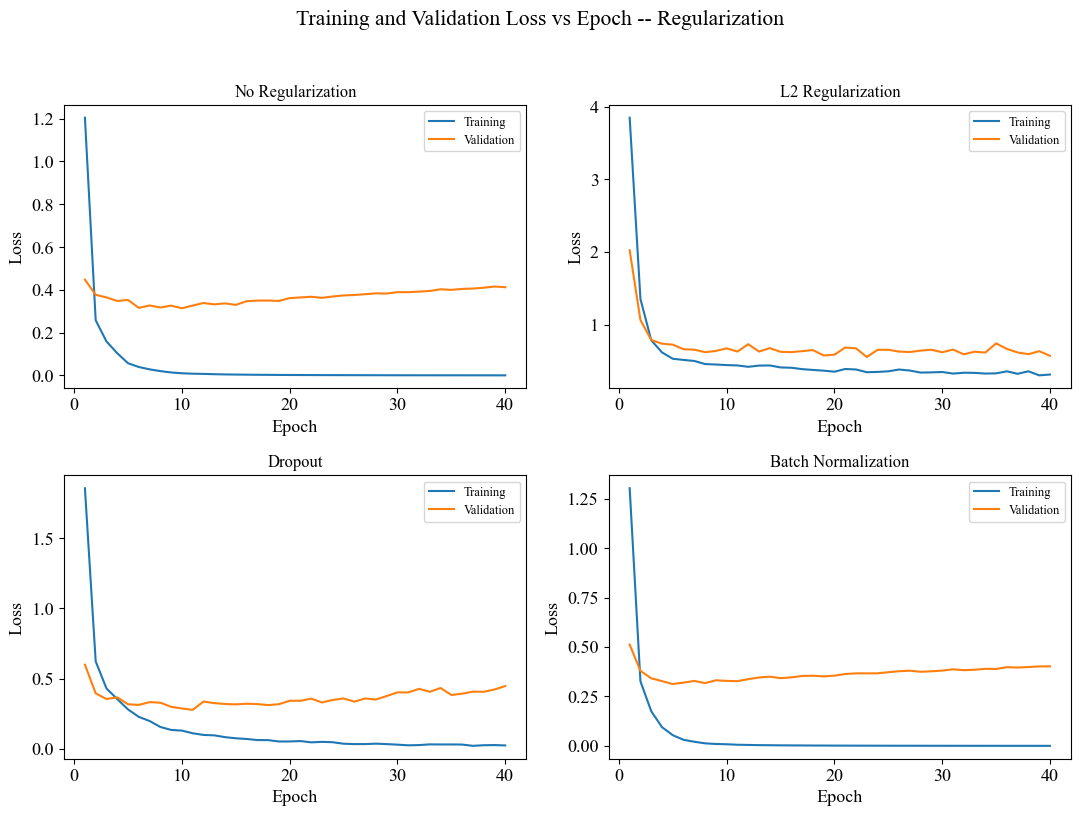

In [16]:
# Plot 4: Training and Validation Loss vs Epoch (one panel per technique)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (name, h) in zip(axes.flat, reg_histories.items()):
    ep = range(1, len(h['loss']) + 1)
    ax.plot(ep, h['loss'], label='Training')
    ax.plot(ep, h['val_loss'], label='Validation')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
fig.suptitle('Training and Validation Loss vs Epoch -- Regularization', y=1.02)
plt.tight_layout()
save_fig(fig, 'plot4_reg_loss')
plt.show()


In [17]:
reg_test_acc = {name: m.evaluate(X_test, y_test, verbose=0)[1] * 100 for name, m in reg_models.items()}
best_reg_name = max(reg_histories, key=lambda n: max(reg_histories[n]['val_accuracy']))
best_reg_cfg = reg_configs[best_reg_name]
print(f"Best regularization: {best_reg_name}")
print("Test accuracy by regularization:", {k: round(v, 2) for k, v in reg_test_acc.items()})


Best regularization: Dropout
Test accuracy by regularization: {'No Regularization': 89.67, 'L2 Regularization': 87.63, 'Dropout': 89.29, 'Batch Normalization': 89.81}


## Section 7: Batch Normalization

### Numerical example (reproducing the manual's worked example)


In [18]:
x = np.array([2, 4, 6, 8], dtype=float)
mu_B = x.mean()
var_B = x.var()
x_hat = (x - mu_B) / np.sqrt(var_B + 1e-8)
gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta

print(f"mu_B    = {mu_B}")
print(f"sigma_B^2 = {var_B}")
print(f"x_hat   = {np.round(x_hat, 3)}")
print(f"y (gamma=1, beta=0) = {np.round(y, 3)}")


mu_B    = 5.0
sigma_B^2 = 5.0
x_hat   = [-1.342 -0.447  0.447  1.342]
y (gamma=1, beta=0) = [-1.342 -0.447  0.447  1.342]


### Plot 5: With vs. Without Batch Normalization

Saved figures/plot5_bn_compare.eps


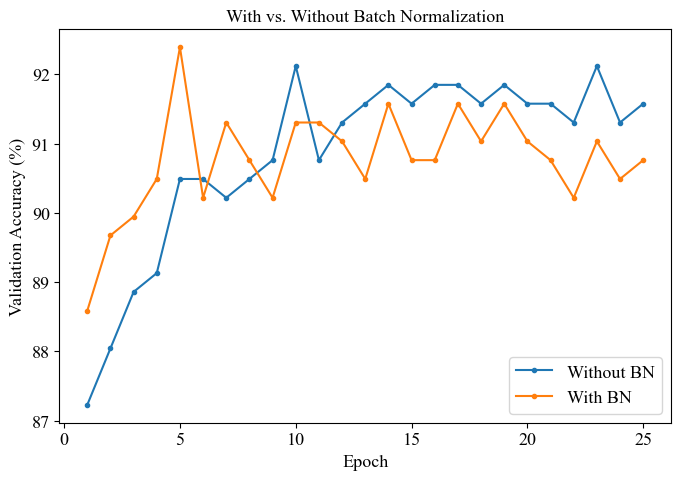

In [19]:
EPOCHS_BN = 25
bn_histories = {}
for name, use_bn in [('Without BN', False), ('With BN', True)]:
    model = build_head(init=best_init, use_bn=use_bn)
    history, _ = compile_and_train(model, tf.keras.optimizers.Adam(0.001),
                                    X_train, y_train, X_val, y_val, epochs=EPOCHS_BN)
    bn_histories[name] = history.history

fig, ax = plt.subplots(figsize=(7, 5))
for name, h in bn_histories.items():
    ax.plot(range(1, len(h['val_accuracy']) + 1), [v * 100 for v in h['val_accuracy']],
            label=name, marker='o', markersize=3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('With vs. Without Batch Normalization')
ax.legend()
plt.tight_layout()
save_fig(fig, 'plot5_bn_compare')
plt.show()


## Section 8: Optimization Algorithms

SGD, Momentum, RMSProp and Adam, all using the best initialisation and best regularisation
found so far, so only the optimizer differs between the four runs.


In [20]:
optimizers = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'Momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSProp': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001),
}

EPOCHS_OPT = 25
opt_histories, opt_models, opt_times = {}, {}, {}

for name, opt in optimizers.items():
    print(f"Training with {name}...")
    model = build_head(init=best_init, **best_reg_cfg)
    history, elapsed = compile_and_train(model, opt, X_train, y_train, X_val, y_val, epochs=EPOCHS_OPT)
    opt_histories[name] = history.history
    opt_models[name] = model
    opt_times[name] = elapsed


Training with SGD...
Training with Momentum...
Training with RMSProp...
Training with Adam...


Saved figures/plot6_opt_train_loss.eps


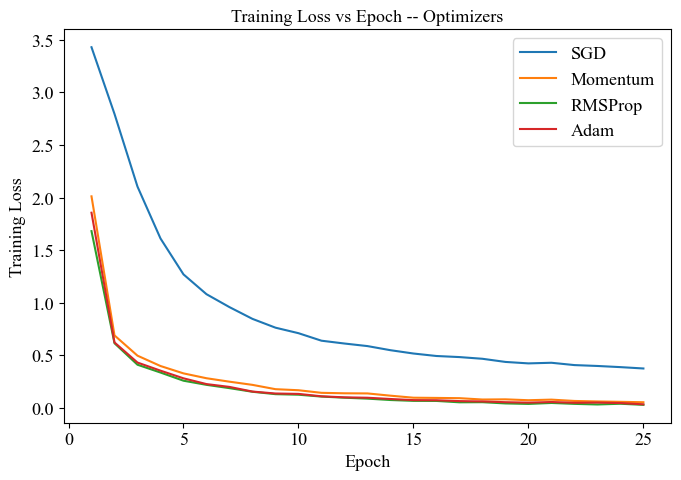

In [21]:
# Plot 6: Training Loss vs Epoch for Different Optimizers
fig, ax = plt.subplots(figsize=(7, 5))
for name, h in opt_histories.items():
    ax.plot(range(1, len(h['loss']) + 1), h['loss'], label=name)
ax.set_xlabel('Epoch'); ax.set_ylabel('Training Loss')
ax.set_title('Training Loss vs Epoch -- Optimizers')
ax.legend()
plt.tight_layout()
save_fig(fig, 'plot6_opt_train_loss')
plt.show()


Saved figures/plot7_opt_val_acc.eps


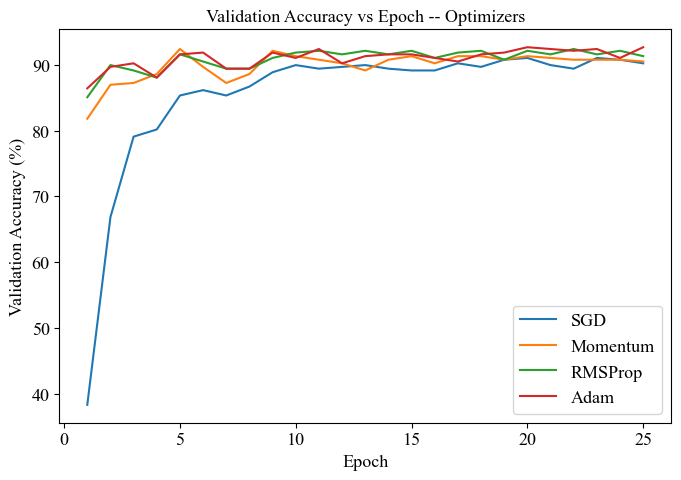

In [22]:
# Plot 7: Validation Accuracy vs Epoch for Different Optimizers
fig, ax = plt.subplots(figsize=(7, 5))
for name, h in opt_histories.items():
    ax.plot(range(1, len(h['val_accuracy']) + 1), [v * 100 for v in h['val_accuracy']], label=name)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Validation Accuracy vs Epoch -- Optimizers')
ax.legend()
plt.tight_layout()
save_fig(fig, 'plot7_opt_val_acc')
plt.show()


In [23]:
def epoch_to_converge(history, threshold_frac=0.95):
    best = max(history['val_accuracy'])
    thresh = threshold_frac * best
    for i, v in enumerate(history['val_accuracy']):
        if v >= thresh:
            return i + 1
    return len(history['val_accuracy'])

opt_test_acc = {name: m.evaluate(X_test, y_test, verbose=0)[1] * 100 for name, m in opt_models.items()}

opt_summary = pd.DataFrame({
    'Optimizer': list(opt_histories.keys()),
    'Final Loss': [h['loss'][-1] for h in opt_histories.values()],
    'Best Val. Accuracy (%)': [max(h['val_accuracy']) * 100 for h in opt_histories.values()],
    'Epoch to Converge': [epoch_to_converge(h) for h in opt_histories.values()],
    'Time (s)': [opt_times[n] for n in opt_histories.keys()],
})
best_opt_name = opt_summary.loc[opt_summary['Best Val. Accuracy (%)'].idxmax(), 'Optimizer']
print(f"Best optimizer: {best_opt_name}")
opt_summary


Best optimizer: Adam


,Optimizer,Final Loss,Best Val. Accuracy (%),Epoch to Converge,Time (s)
0,SGD,0.373903,91.032606,8,4.904763
1,Momentum,0.052867,92.391306,4,4.985394
2,RMSProp,0.028087,92.391306,2,5.646330
3,Adam,0.032727,92.663044,2,4.945991


## Section 9: CNN Hyperparameter Tuning

A **controlled** one-at-a-time sweep, exactly as the manual specifies ("change one
hyperparameter at a time while keeping the remaining settings fixed"). The starting point for
each sweep is the best initialisation, best regularisation, and best optimizer found in the
sections above; only the hyperparameter under study is varied. Values are taken directly from
the manual's suggested-values table.


Saved figures/plot8_lr_vs_valacc.eps


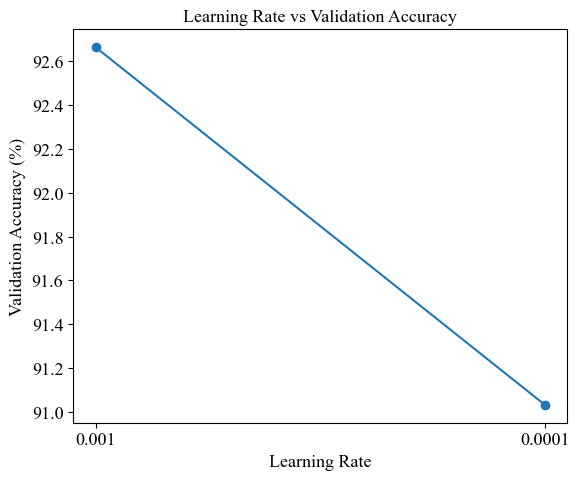

Best learning rate: 0.001


In [24]:
EPOCHS_HP = 20

# --- Learning Rate sweep: 0.001, 0.0001 ---
lr_values = [0.001, 0.0001]
lr_results = {}
for lr in lr_values:
    model = build_head(init=best_init, **best_reg_cfg)
    opt = make_optimizer(best_opt_name, lr)
    history, _ = compile_and_train(model, opt, X_train, y_train, X_val, y_val,
                                    epochs=EPOCHS_HP, batch_size=32)
    lr_results[lr] = max(history.history['val_accuracy']) * 100

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([str(v) for v in lr_results.keys()], list(lr_results.values()), marker='o')
ax.set_xlabel('Learning Rate'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Learning Rate vs Validation Accuracy')
plt.tight_layout()
save_fig(fig, 'plot8_lr_vs_valacc')
plt.show()

best_lr = max(lr_results, key=lr_results.get)
print(f"Best learning rate: {best_lr}")


Saved figures/plot9_batch_vs_valacc.eps


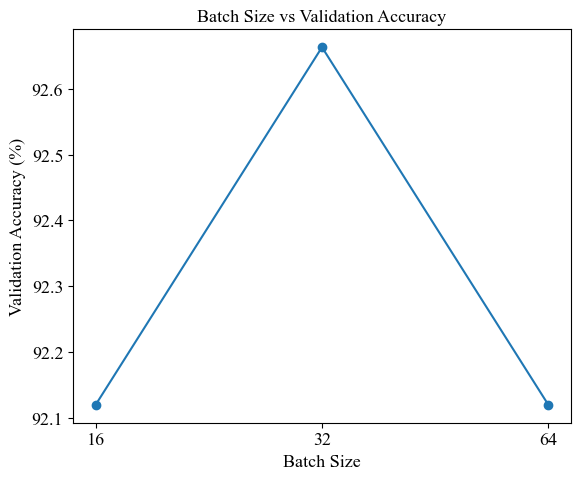

Best batch size: 32


In [25]:
# --- Batch Size sweep: 16, 32, 64 ---
batch_values = [16, 32, 64]
batch_results = {}
for bs in batch_values:
    model = build_head(init=best_init, **best_reg_cfg)
    opt = make_optimizer(best_opt_name, best_lr)
    history, _ = compile_and_train(model, opt, X_train, y_train, X_val, y_val,
                                    epochs=EPOCHS_HP, batch_size=bs)
    batch_results[bs] = max(history.history['val_accuracy']) * 100

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([str(v) for v in batch_results.keys()], list(batch_results.values()), marker='o')
ax.set_xlabel('Batch Size'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Batch Size vs Validation Accuracy')
plt.tight_layout()
save_fig(fig, 'plot9_batch_vs_valacc')
plt.show()

best_batch = max(batch_results, key=batch_results.get)
print(f"Best batch size: {best_batch}")


Saved figures/plot10_dropout_vs_valacc.eps


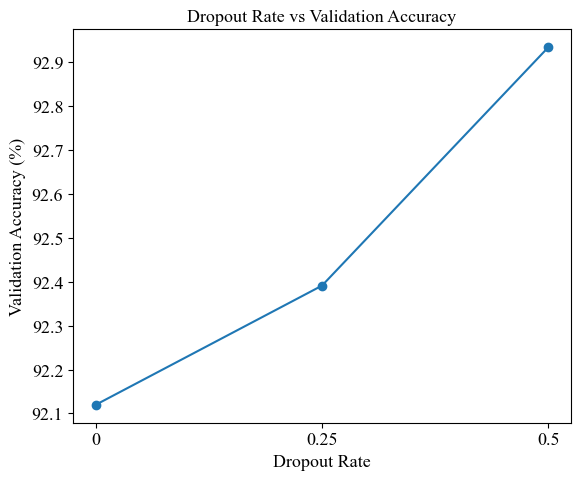

Best dropout rate: 0.5

Best combined hyperparameters -> LR: 0.001, Batch: 32, Dropout: 0.5


In [26]:
# --- Dropout Rate sweep: 0, 0.25, 0.5 ---
dropout_values = [0, 0.25, 0.5]
dropout_results = {}
for dr in dropout_values:
    model = build_head(init=best_init, reg=None, dropout_rate=dr, use_bn=False)
    opt = make_optimizer(best_opt_name, best_lr)
    history, _ = compile_and_train(model, opt, X_train, y_train, X_val, y_val,
                                    epochs=EPOCHS_HP, batch_size=best_batch)
    dropout_results[dr] = max(history.history['val_accuracy']) * 100

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([str(v) for v in dropout_results.keys()], list(dropout_results.values()), marker='o')
ax.set_xlabel('Dropout Rate'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Dropout Rate vs Validation Accuracy')
plt.tight_layout()
save_fig(fig, 'plot10_dropout_vs_valacc')
plt.show()

best_dropout = max(dropout_results, key=dropout_results.get)
print(f"Best dropout rate: {best_dropout}")
print(f"\nBest combined hyperparameters -> LR: {best_lr}, Batch: {best_batch}, Dropout: {best_dropout}")


In [27]:
# Train and evaluate one model at the best combined hyperparameters, for the Overall Results table
best_hp_model = build_head(init=best_init, reg=None, dropout_rate=best_dropout, use_bn=False)
best_hp_opt = make_optimizer(best_opt_name, best_lr)
best_hp_history, best_hp_time = compile_and_train(
    best_hp_model, best_hp_opt, X_train, y_train, X_val, y_val,
    epochs=EPOCHS_HP, batch_size=best_batch
)
best_hp_test_loss, best_hp_test_acc = best_hp_model.evaluate(X_test, y_test, verbose=0)
print(f"Best-hyperparameters model -- val acc: {max(best_hp_history.history['val_accuracy'])*100:.2f}%, "
      f"test acc: {best_hp_test_acc*100:.2f}%")


Best-hyperparameters model -- val acc: 92.39%, test acc: 89.64%


## Section 10: Transfer Learning and Fine-Tuning

This section trains real end-to-end models on actual images (not cached features), because
Case B unfreezes part of the backbone. Case A (Feature Extraction) is trained for the combined
number of epochs used in Case A + Case B below, so Plot 11 compares two runs of equal total
length: one that stays frozen throughout, and one that switches to fine-tuning partway through.


In [28]:
def build_full_model(head_init, dropout_rate):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet', pooling='avg'
    )
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = tf.keras.layers.Dense(128, activation='relu', kernel_initializer=head_init)(x)
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', kernel_initializer=head_init)(x)
    return tf.keras.Model(inputs, outputs), base

def preprocess_onehot(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

def make_ds_onehot(ds, batch_size, shuffle=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(preprocess_onehot, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds_oh = make_ds_onehot(train_raw, batch_size=best_batch, shuffle=True)
val_ds_oh = make_ds_onehot(val_raw, batch_size=best_batch)
test_ds_oh = make_ds_onehot(test_raw, batch_size=best_batch)

EPOCHS_FE = 15
EPOCHS_FT = 6
EPOCHS_TOTAL = EPOCHS_FE + EPOCHS_FT


In [29]:
# Case A: Feature Extraction only, run for the full EPOCHS_TOTAL epochs as the control curve
print("Case A: Feature Extraction (frozen backbone)...")
model_fe, base_fe = build_full_model(best_init, best_dropout)
base_fe.trainable = False
model_fe.compile(optimizer=make_optimizer(best_opt_name, best_lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
history_fe = model_fe.fit(train_ds_oh, validation_data=val_ds_oh, epochs=EPOCHS_TOTAL, verbose=1)
time_fe = time.time() - t0


Case A: Feature Extraction (frozen backbone)...
Epoch 1/21
104/104 [==============================] - 4s 21ms/step - loss: 1.7813 - accuracy: 0.5444 - val_loss: 0.5507 - val_accuracy: 0.8614
Epoch 2/21
104/104 [==============================] - 2s 18ms/step - loss: 0.6065 - accuracy: 0.8113 - val_loss: 0.4246 - val_accuracy: 0.8696
Epoch 3/21
104/104 [==============================] - 2s 18ms/step - loss: 0.4119 - accuracy: 0.8681 - val_loss: 0.3449 - val_accuracy: 0.9049
Epoch 4/21
104/104 [==============================] - 2s 18ms/step - loss: 0.3269 - accuracy: 0.9052 - val_loss: 0.3273 - val_accuracy: 0.9022
Epoch 5/21
104/104 [==============================] - 2s 18ms/step - loss: 0.2578 - accuracy: 0.9212 - val_loss: 0.3137 - val_accuracy: 0.8886
Epoch 6/21
104/104 [==============================] - 2s 17ms/step - loss: 0.2088 - accuracy: 0.9372 - val_loss: 0.3112 - val_accuracy: 0.9103
Epoch 7/21
104/104 [==============================] - 2s 17ms/step - loss: 0.1876 - accuracy: 

In [30]:
# Case B: Feature extraction for EPOCHS_FE, then unfreeze the last 30 layers and fine-tune for EPOCHS_FT
print("Case B: Feature Extraction stage...")
model_ft, base_ft = build_full_model(best_init, best_dropout)
base_ft.trainable = False
model_ft.compile(optimizer=make_optimizer(best_opt_name, best_lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
history_ft_1 = model_ft.fit(train_ds_oh, validation_data=val_ds_oh, epochs=EPOCHS_FE, verbose=1)
time_ft_1 = time.time() - t0

print("Case B: Fine-Tuning stage (last 30 layers unfrozen, low learning rate)...")
base_ft.trainable = True
for layer in base_ft.layers[:-30]:
    layer.trainable = False

FINE_TUNE_LR = 1e-5
model_ft.compile(optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
                  loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
history_ft_2 = model_ft.fit(train_ds_oh, validation_data=val_ds_oh, epochs=EPOCHS_FT, verbose=1)
time_ft_2 = time.time() - t0

total_ft_time = time_ft_1 + time_ft_2

def combine(h1, h2):
    return {k: h1.history[k] + h2.history[k] for k in h1.history}

history_ft_combined = combine(history_ft_1, history_ft_2)


Case B: Feature Extraction stage...
Epoch 1/15
104/104 [==============================] - 4s 23ms/step - loss: 1.8763 - accuracy: 0.5057 - val_loss: 0.6309 - val_accuracy: 0.8560
Epoch 2/15
104/104 [==============================] - 2s 17ms/step - loss: 0.6071 - accuracy: 0.8137 - val_loss: 0.4105 - val_accuracy: 0.8940
Epoch 3/15
104/104 [==============================] - 2s 17ms/step - loss: 0.4335 - accuracy: 0.8641 - val_loss: 0.3809 - val_accuracy: 0.8859
Epoch 4/15
104/104 [==============================] - 2s 17ms/step - loss: 0.3259 - accuracy: 0.8976 - val_loss: 0.3551 - val_accuracy: 0.9049
Epoch 5/15
104/104 [==============================] - 2s 16ms/step - loss: 0.2698 - accuracy: 0.9170 - val_loss: 0.3451 - val_accuracy: 0.9049
Epoch 6/15
104/104 [==============================] - 2s 16ms/step - loss: 0.2277 - accuracy: 0.9296 - val_loss: 0.3155 - val_accuracy: 0.9076
Epoch 7/15
104/104 [==============================] - 2s 16ms/step - loss: 0.1841 - accuracy: 0.9457 - val

Saved figures/plot11_fe_vs_ft.eps


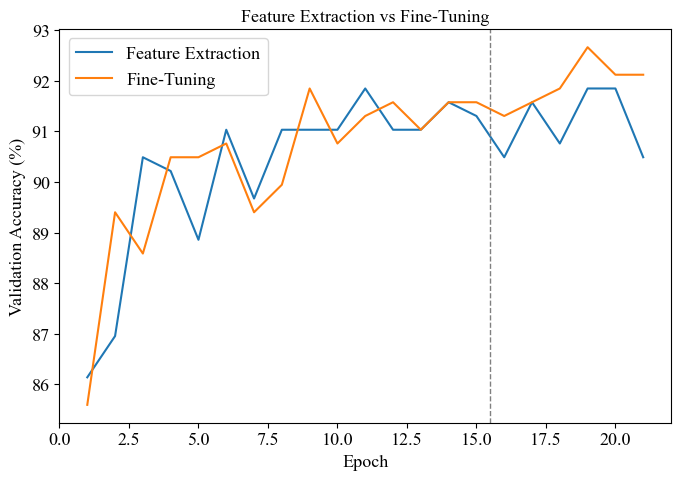

In [31]:
# Plot 11: Feature Extraction vs Fine-Tuning
fig, ax = plt.subplots(figsize=(7, 5))
epochs_axis = range(1, EPOCHS_TOTAL + 1)
ax.plot(epochs_axis, [v * 100 for v in history_fe.history['val_accuracy']], label='Feature Extraction')
ax.plot(epochs_axis, [v * 100 for v in history_ft_combined['val_accuracy']], label='Fine-Tuning')
ax.axvline(EPOCHS_FE + 0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Feature Extraction vs Fine-Tuning')
ax.legend()
plt.tight_layout()
save_fig(fig, 'plot11_fe_vs_ft')
plt.show()


Saved figures/plot12_ft_loss.eps


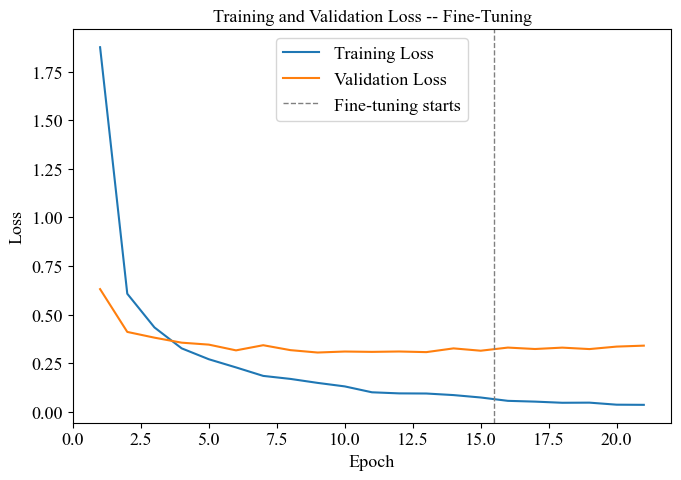

In [32]:
# Plot 12: Training and Validation Loss, before and after fine-tuning
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_axis, history_ft_combined['loss'], label='Training Loss')
ax.plot(epochs_axis, history_ft_combined['val_loss'], label='Validation Loss')
ax.axvline(EPOCHS_FE + 0.5, color='gray', linestyle='--', linewidth=1, label='Fine-tuning starts')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss -- Fine-Tuning')
ax.legend()
plt.tight_layout()
save_fig(fig, 'plot12_ft_loss')
plt.show()


In [33]:
fe_test_loss, fe_test_acc = model_fe.evaluate(test_ds_oh, verbose=0)
ft_test_loss, ft_test_acc = model_ft.evaluate(test_ds_oh, verbose=0)
print(f"Feature-extraction-only test accuracy: {fe_test_acc*100:.2f}%")
print(f"Fine-tuned test accuracy: {ft_test_acc*100:.2f}%")


Feature-extraction-only test accuracy: 90.00%
Fine-tuned test accuracy: 89.97%


## Section 11: K-Fold Cross-Validation

Four promising configurations are selected from the studies above. All four are frozen-backbone
(feature-extraction) configurations trained on cached bottleneck features -- fine-tuning is left
out of cross-validation because unfreezing the backbone for 4 configurations x 5 folds would mean
20 full end-to-end training runs, which is not practical for a lab setting (the same kind of
computational trade-off made in Experiment 4's hyperparameter search). Cross-validation uses only
the combined training + validation data; the test set is not touched here.


In [34]:
X_trainval = np.concatenate([X_train, X_val])
y_trainval_int = np.concatenate([y_train_int, y_val_int])
y_trainval = tf.keras.utils.to_categorical(y_trainval_int, NUM_CLASSES)

configs_cv = {
    'C1: Best Init Only': dict(init=best_init, reg=None, dropout_rate=0.0, use_bn=False,
                                lr=0.001, optimizer_name='Adam', batch=32),
    'C2: Best Init + Best Reg': dict(init=best_init, **best_reg_cfg, lr=0.001,
                                      optimizer_name='Adam', batch=32),
    'C3: Best Init + Best Reg + Best Optimizer': dict(init=best_init, **best_reg_cfg, lr=0.001,
                                                        optimizer_name=best_opt_name, batch=32),
    'C4: Best Hyperparameters': dict(init=best_init, reg=None, dropout_rate=best_dropout, use_bn=False,
                                      lr=best_lr, optimizer_name=best_opt_name, batch=best_batch),
}

EPOCHS_CV = 15
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for cfg_name, cfg in configs_cv.items():
    fold_accs = []
    for fold_i, (tr_idx, va_idx) in enumerate(skf.split(X_trainval, y_trainval_int)):
        model = build_head(init=cfg['init'], reg=cfg.get('reg'),
                            dropout_rate=cfg.get('dropout_rate', 0.0), use_bn=cfg.get('use_bn', False))
        opt = make_optimizer(cfg['optimizer_name'], cfg['lr'])
        model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
        model.fit(X_trainval[tr_idx], y_trainval[tr_idx],
                  validation_data=(X_trainval[va_idx], y_trainval[va_idx]),
                  epochs=EPOCHS_CV, batch_size=cfg['batch'], verbose=0)
        _, acc = model.evaluate(X_trainval[va_idx], y_trainval[va_idx], verbose=0)
        fold_accs.append(acc * 100)
        print(f"{cfg_name} -- fold {fold_i + 1}: {acc*100:.2f}%")
    cv_results[cfg_name] = fold_accs


C1: Best Init Only -- fold 1: 91.17%
C1: Best Init Only -- fold 2: 91.58%
C1: Best Init Only -- fold 3: 92.93%
C1: Best Init Only -- fold 4: 91.98%
C1: Best Init Only -- fold 5: 91.17%
C2: Best Init + Best Reg -- fold 1: 90.76%
C2: Best Init + Best Reg -- fold 2: 91.30%
C2: Best Init + Best Reg -- fold 3: 93.07%
C2: Best Init + Best Reg -- fold 4: 92.39%
C2: Best Init + Best Reg -- fold 5: 91.85%
C3: Best Init + Best Reg + Best Optimizer -- fold 1: 90.76%
C3: Best Init + Best Reg + Best Optimizer -- fold 2: 91.44%
C3: Best Init + Best Reg + Best Optimizer -- fold 3: 92.66%
C3: Best Init + Best Reg + Best Optimizer -- fold 4: 92.26%
C3: Best Init + Best Reg + Best Optimizer -- fold 5: 91.30%
C4: Best Hyperparameters -- fold 1: 90.76%
C4: Best Hyperparameters -- fold 2: 91.44%
C4: Best Hyperparameters -- fold 3: 92.93%
C4: Best Hyperparameters -- fold 4: 91.98%
C4: Best Hyperparameters -- fold 5: 91.30%


In [35]:
cv_table = pd.DataFrame(cv_results).T
cv_table.columns = [f'F{i+1}' for i in range(5)]
cv_table['Mean'] = cv_table[[f'F{i+1}' for i in range(5)]].mean(axis=1)
cv_table['SD'] = cv_table[[f'F{i+1}' for i in range(5)]].std(axis=1)
cv_table


,F1,F2,F3,F4,F5,Mean,SD
C1: Best Init Only,91.168481,91.576087,92.934781,91.983694,91.168481,91.766305,0.735453
C2: Best Init + Best Reg,90.760869,91.304350,93.070650,92.391306,91.847825,91.875000,0.903302
C3: Best Init + Best Reg + Best Optimizer,90.760869,91.440219,92.663044,92.255437,91.304350,91.684784,0.764983
C4: Best Hyperparameters,90.760869,91.440219,92.934781,91.983694,91.304350,91.684783,0.823104


Saved figures/plot13_cv_results.eps


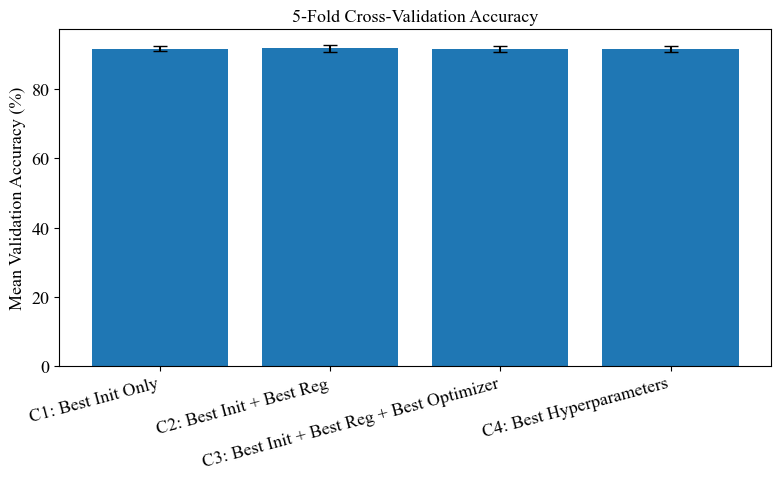

Best CV configuration: C2: Best Init + Best Reg


In [36]:
# Plot 13: 5-Fold Cross-Validation Accuracy with SD error bars
fig, ax = plt.subplots(figsize=(8, 5))
names = list(cv_results.keys())
means = cv_table.loc[names, 'Mean']
sds = cv_table.loc[names, 'SD']
ax.bar(names, means, yerr=sds, capsize=5)
ax.set_ylabel('Mean Validation Accuracy (%)')
ax.set_title('5-Fold Cross-Validation Accuracy')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
save_fig(fig, 'plot13_cv_results')
plt.show()

best_cv_config_name = cv_table['Mean'].idxmax()
print(f"Best CV configuration: {best_cv_config_name}")


## Section 12: Final Model Evaluation

The configuration with the best mean cross-validation accuracy is retrained on the full
training + validation data, then evaluated once on the untouched test set.


In [37]:
best_cfg = configs_cv[best_cv_config_name]

final_model = build_head(init=best_cfg['init'], reg=best_cfg.get('reg'),
                          dropout_rate=best_cfg.get('dropout_rate', 0.0),
                          use_bn=best_cfg.get('use_bn', False))
final_opt = make_optimizer(best_cfg['optimizer_name'], best_cfg['lr'])
final_model.compile(optimizer=final_opt, loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
final_model.fit(X_trainval, y_trainval, epochs=EPOCHS_CV, batch_size=best_cfg['batch'], verbose=1)
final_train_time = time.time() - t0

test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
y_pred_probs = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(y_test_int, y_pred, average='weighted')
n_params = final_model.count_params()

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Weighted Precision: {precision*100:.2f}%  Weighted Recall: {recall*100:.2f}%  Weighted F1: {f1*100:.2f}%")
print(f"Training Time: {final_train_time:.2f}s   Parameters: {n_params}")


Epoch 1/15
115/115 [==============================] - 0s 1ms/step - loss: 1.7592 - accuracy: 0.5310
Epoch 2/15
115/115 [==============================] - 0s 1ms/step - loss: 0.6066 - accuracy: 0.8163
Epoch 3/15
115/115 [==============================] - 0s 1ms/step - loss: 0.4101 - accuracy: 0.8761
Epoch 4/15
115/115 [==============================] - 0s 1ms/step - loss: 0.3140 - accuracy: 0.9065
Epoch 5/15
115/115 [==============================] - 0s 1ms/step - loss: 0.2592 - accuracy: 0.9234
Epoch 6/15
115/115 [==============================] - 0s 2ms/step - loss: 0.2176 - accuracy: 0.9310
Epoch 7/15
115/115 [==============================] - 0s 1ms/step - loss: 0.1962 - accuracy: 0.9394
Epoch 8/15
115/115 [==============================] - 0s 1ms/step - loss: 0.1592 - accuracy: 0.9489
Epoch 9/15
115/115 [==============================] - 0s 1ms/step - loss: 0.1488 - accuracy: 0.9546
Epoch 10/15
115/115 [==============================] - 0s 1ms/step - loss: 0.1202 - accuracy: 0.9620

In [38]:
final_metrics = pd.DataFrame({
    'Metric': ['Mean CV Accuracy', 'CV Standard Deviation', 'Test Accuracy', 'Precision',
               'Recall', 'F1-score', 'Training Time', 'Number of Parameters'],
    'Value': [
        f"{cv_table.loc[best_cv_config_name, 'Mean']:.2f}%",
        f"{cv_table.loc[best_cv_config_name, 'SD']:.2f}",
        f"{test_acc*100:.2f}%",
        f"{precision*100:.2f}%",
        f"{recall*100:.2f}%",
        f"{f1*100:.2f}%",
        f"{final_train_time:.2f}s",
        n_params,
    ]
})
final_metrics


,Metric,Value
0,Mean CV Accuracy,91.88%
1,CV Standard Deviation,0.90
2,Test Accuracy,90.46%
3,Precision,90.97%
4,Recall,90.46%
5,F1-score,90.45%
6,Training Time,2.63s
7,Number of Parameters,168741


In [39]:
report = classification_report(y_test_int, y_pred, target_names=CLASS_NAMES, output_dict=True)
report_df = pd.DataFrame(report).T
report_df


,precision,recall,f1-score,support
Abyssinian,0.824074,0.908163,0.864078,98.000000
american_bulldog,0.752066,0.910000,0.823529,100.000000
american_pit_bull_terrier,0.820896,0.550000,0.658683,100.000000
basset_hound,1.000000,0.820000,0.901099,100.000000
beagle,0.842105,0.960000,0.897196,100.000000
Bengal,0.798165,0.870000,0.832536,100.000000
Birman,0.752212,0.850000,0.798122,100.000000
Bombay,0.897727,0.897727,0.897727,88.000000
boxer,0.913043,0.848485,0.879581,99.000000
British_Shorthair,0.950617,0.770000,0.850829,100.000000


Saved figures/plot14_confusion_matrix.eps


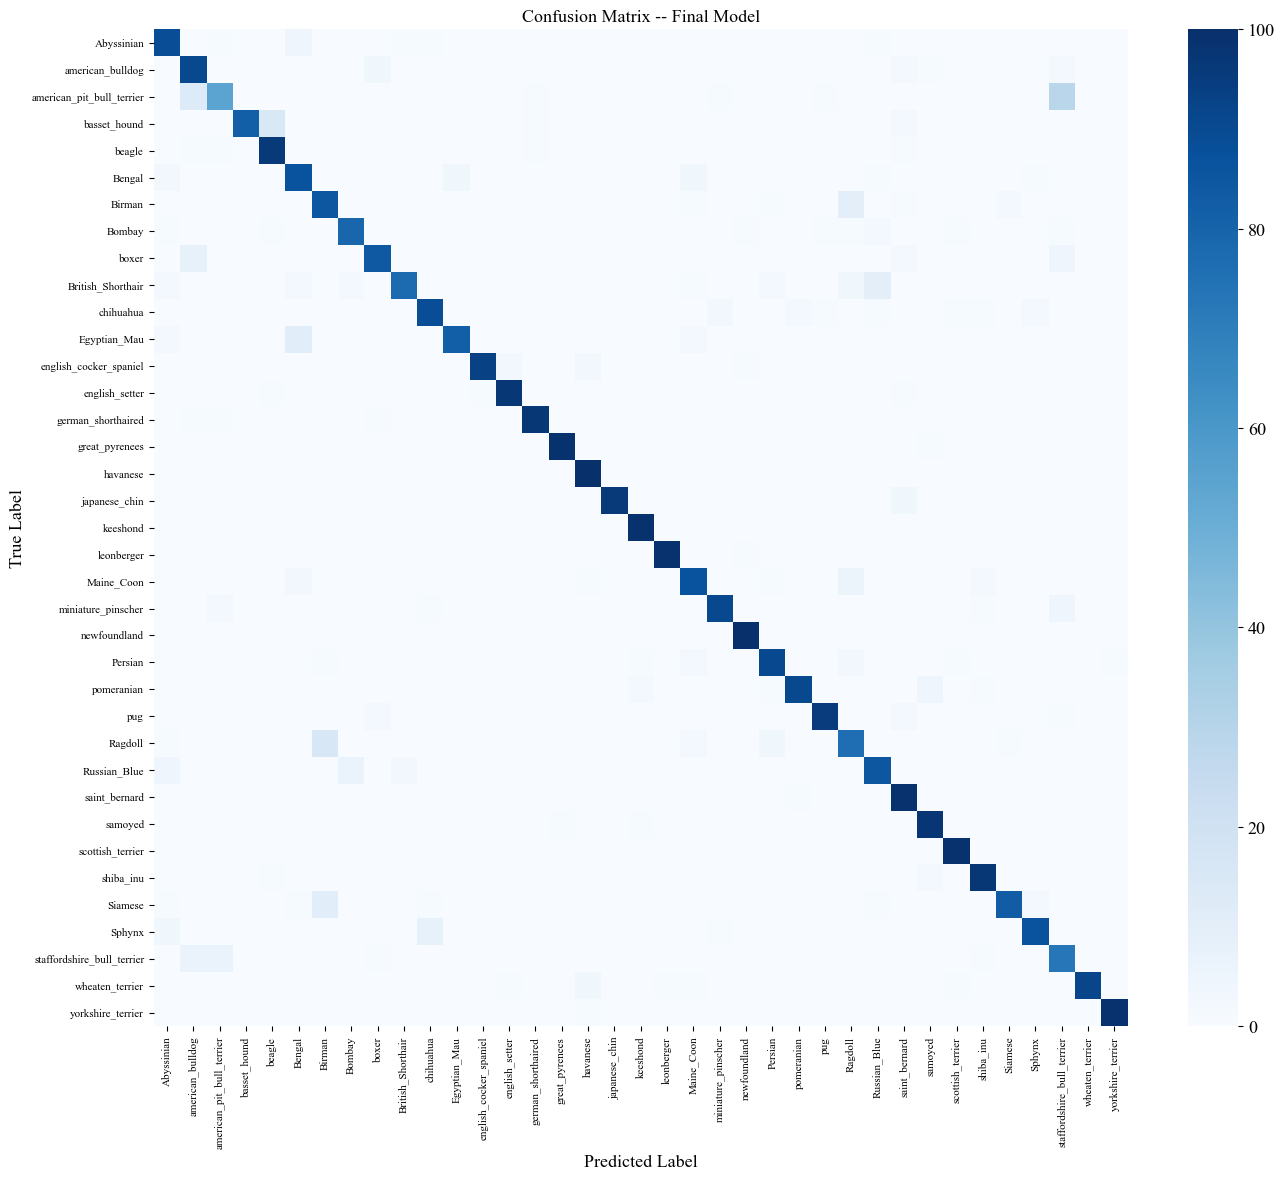

In [40]:
# Plot 14: Confusion Matrix
cm = confusion_matrix(y_test_int, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix -- Final Model')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
save_fig(fig, 'plot14_confusion_matrix')
plt.show()


Saved figures/plot15_misclassified.eps


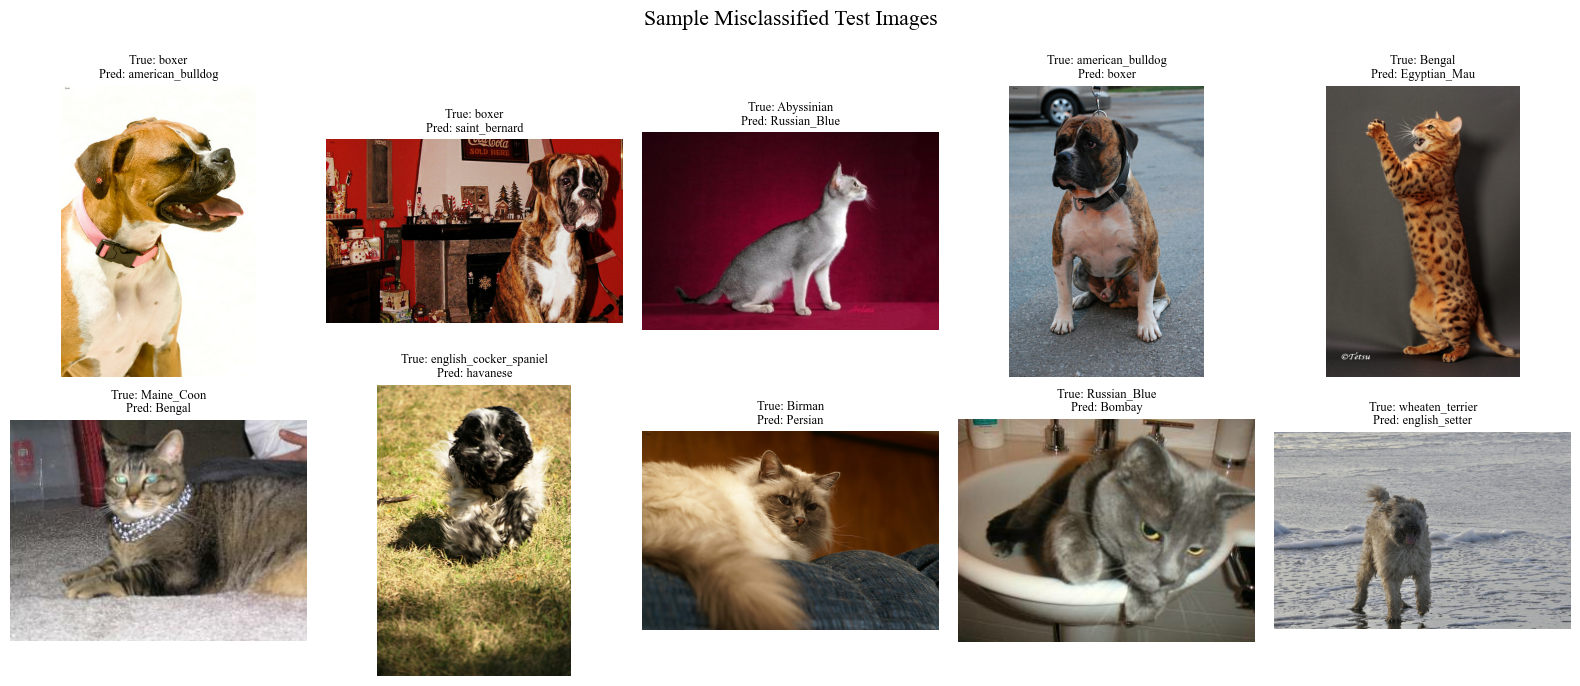

In [41]:
# Plot 15 (optional): Sample Misclassified Test Images
misclassified_idx = np.where(y_pred != y_test_int)[0]
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(misclassified_idx, size=min(10, len(misclassified_idx)), replace=False)

raw_test_images = [img.numpy() for img, _ in test_raw]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(raw_test_images[idx])
    ax.set_title(f"True: {CLASS_NAMES[y_test_int[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}", fontsize=9)
    ax.axis('off')
fig.suptitle('Sample Misclassified Test Images')
plt.tight_layout()
save_fig(fig, 'plot15_misclassified')
plt.show()


## Section 13: Overall Results

Reference values for Baseline, Best Initialization, Best Regularization and Best Optimizer are
their own validation accuracy and test accuracy (they were not run through 5-fold CV
individually). Best Hyperparameters and the Fine-Tuned Model likewise report validation
accuracy and test accuracy. Only the four configurations in Section 11 have a true CV mean and
SD -- these are reported separately in the `cv_table` above.


In [42]:
overall_results = pd.DataFrame({
    'Configuration': ['Baseline', 'Best Initialization', 'Best Regularization',
                       'Best Optimizer', 'Best Hyperparameters', 'Fine-Tuned Model'],
    'Val. Accuracy (%)': [
        max(baseline_history.history['val_accuracy']) * 100,
        max(init_histories[best_init_name]['val_accuracy']) * 100,
        max(reg_histories[best_reg_name]['val_accuracy']) * 100,
        max(opt_histories[best_opt_name]['val_accuracy']) * 100,
        max(best_hp_history.history['val_accuracy']) * 100,
        max(history_ft_combined['val_accuracy']) * 100,
    ],
    'Test Accuracy (%)': [
        baseline_test_acc * 100,
        init_test_acc[best_init_name],
        reg_test_acc[best_reg_name],
        opt_test_acc[best_opt_name],
        best_hp_test_acc * 100,
        ft_test_acc * 100,
    ],
    'Training Time (s)': [
        baseline_time,
        init_times[best_init_name],
        reg_times[best_reg_name],
        opt_times[best_opt_name],
        best_hp_time,
        total_ft_time,
    ],
})
overall_results


,Configuration,Val. Accuracy (%),Test Accuracy (%),Training Time (s)
0,Baseline,92.934781,90.433359,3.483099
1,Best Initialization,92.119563,89.970016,3.816975
2,Best Regularization,93.206519,89.288634,7.625620
3,Best Optimizer,92.663044,90.188062,4.945991
4,Best Hyperparameters,92.391306,89.642954,4.277788
5,Fine-Tuned Model,92.663044,89.970016,45.998437


## Section 16: Additional Exercise

Two new hyperparameter combinations (learning rate, dropout, batch size), both using a frozen
backbone for the same computational-feasibility reason as Section 11, evaluated with 5-fold
cross-validation and compared against the configuration selected in Section 11.


In [43]:
new_combos = {
    'New Combo 1 (LR=0.0005, Dropout=0.3, Batch=48)': dict(
        init=best_init, reg=None, dropout_rate=0.3, use_bn=False,
        lr=0.0005, optimizer_name=best_opt_name, batch=48),
    'New Combo 2 (LR=0.0003, Dropout=0.6, Batch=24)': dict(
        init=best_init, reg=None, dropout_rate=0.6, use_bn=False,
        lr=0.0003, optimizer_name=best_opt_name, batch=24),
}

additional_cv_results = {}
for cfg_name, cfg in new_combos.items():
    fold_accs = []
    for fold_i, (tr_idx, va_idx) in enumerate(skf.split(X_trainval, y_trainval_int)):
        model = build_head(init=cfg['init'], reg=cfg.get('reg'),
                            dropout_rate=cfg.get('dropout_rate', 0.0), use_bn=cfg.get('use_bn', False))
        opt = make_optimizer(cfg['optimizer_name'], cfg['lr'])
        model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
        model.fit(X_trainval[tr_idx], y_trainval[tr_idx],
                  validation_data=(X_trainval[va_idx], y_trainval[va_idx]),
                  epochs=EPOCHS_CV, batch_size=cfg['batch'], verbose=0)
        _, acc = model.evaluate(X_trainval[va_idx], y_trainval[va_idx], verbose=0)
        fold_accs.append(acc * 100)
    additional_cv_results[cfg_name] = fold_accs
    print(f"{cfg_name}: {[round(a, 2) for a in fold_accs]}")


New Combo 1 (LR=0.0005, Dropout=0.3, Batch=48): [90.9, 91.03, 92.93, 91.85, 91.58]
New Combo 2 (LR=0.0003, Dropout=0.6, Batch=24): [90.62, 91.17, 92.53, 91.98, 91.44]


In [44]:
additional_table = pd.DataFrame(additional_cv_results).T
additional_table.columns = [f'F{i+1}' for i in range(5)]
additional_table['Mean'] = additional_table[[f'F{i+1}' for i in range(5)]].mean(axis=1)
additional_table['SD'] = additional_table[[f'F{i+1}' for i in range(5)]].std(axis=1)

comparison_table = pd.concat([cv_table.loc[[best_cv_config_name]], additional_table])
comparison_table


,F1,F2,F3,F4,F5,Mean,SD
C2: Best Init + Best Reg,90.760869,91.304350,93.070650,92.391306,91.847825,91.875000,0.903302
"New Combo 1 (LR=0.0005, Dropout=0.3, Batch=48)",90.896738,91.032606,92.934781,91.847825,91.576087,91.657608,0.812950
"New Combo 2 (LR=0.0003, Dropout=0.6, Batch=24)",90.625000,91.168481,92.527175,91.983694,91.440219,91.548914,0.734198


## Study Notes (for understanding, not part of the graded deliverable)

- **Zero initialization** makes every neuron in a layer compute the same gradient, so they
  never differentiate from each other (the symmetry problem) -- expect it to be the worst
  performer above.
- **Xavier/Glorot** init sets the initial variance based on both fan-in and fan-out, and pairs
  well with sigmoid/tanh activations. **He** init only accounts for fan-in and multiplies by 2,
  which suits ReLU activations (since ReLU zeroes out roughly half the pre-activations).
- **L2 regularization** penalises large weights directly in the loss function. **Dropout**
  randomly zeroes activations during training so the network can't rely on any single neuron.
  **Batch Normalization** normalises layer inputs per mini-batch, which incidentally also has a
  mild regularising effect because the statistics change slightly from batch to batch.
- **SGD** takes a fixed step in the direction of the current gradient. **Momentum** adds a
  running average of past gradients so the optimizer keeps moving through small local bumps.
  **RMSProp** divides the learning rate by a running average of recent squared gradients, so
  parameters with large recent gradients get smaller steps. **Adam** combines both ideas
  (momentum + per-parameter adaptive scaling).
- **Feature extraction** trains only the new head; the pretrained convolutional filters never
  change. **Fine-tuning** unfreezes some of those filters and continues training them, usually
  at a much lower learning rate, so the large gradients coming from the freshly-initialised head
  do not wreck the pretrained features.
- **K-Fold Cross-Validation** trains and evaluates a configuration K times on different splits
  of the training data, so the mean accuracy is less sensitive to which specific images ended up
  in a single validation split, and the standard deviation says how much that choice of split
  matters.
